In [1]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import inspect
from os.path import join
import sys
sys.path.append("../../mymodule")
from utilfunc import *

In [2]:
print(inspect.signature(plotBackProjection))

(dataDict, plane_point, plane_normal=array([0, 0, 1]), xRange=(-50, 50), yRange=(-50, 50), numBinsXY=200, numBinsX=None, numBinsY=None, title=None, figName=None, spread_arm=np.float64(0.05235987755982989), num_points=1000)


In [3]:
plane_normal = np.array([1,0,0])
plane_point  = np.array([50,0,0])

Num. of Events:  326


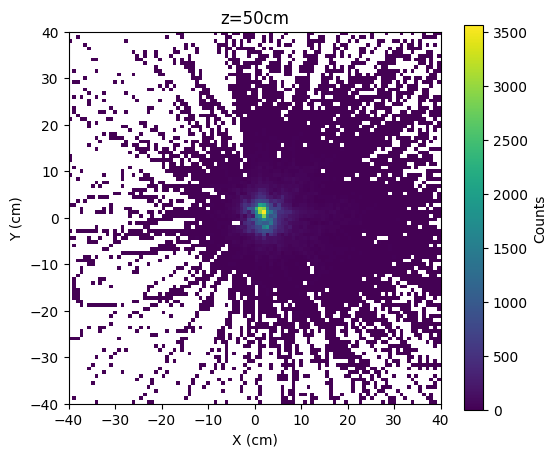

In [7]:
dirData = "../../products"
fileNameList = ["compton_merged.root"]

for fileName in fileNameList:
    filePath = join(dirData, fileName)
    
    branchList = ["hit1_energy", "hit1_posx", "hit1_posy", "hit1_posz", 
                  "hit2_energy", "hit2_posx", "hit2_posy", "hit2_posz", 
                  "costheta"]
    dataDict = uproot.open(f"{filePath}:cetree").arrays(branchList, cut="num_hits==2", library="np")
    dataDict["theta_k"] = np.acos(dataDict["costheta"])
    print("Num. of Events: ", len(dataDict["hit1_energy"]))

    plotBackProjection(dataDict, plane_point, numBinsX=100, numBinsY=100, 
                       spread_arm=np.deg2rad(0.001), title="z=50cm", 
                       xRange=(-40,40), yRange=(-40,40))